In [19]:
import sys
sys.path.append("../KAIR")

import matplotlib.pyplot as plt
import numpy as np
import torch

from utils import utils_image, utils_model

In [8]:
def imshow(ax, img, **kwargs):
    ax.imshow(np.clip(img, 0, 1), **kwargs)

## Load base image here.
You may check for other color images in the specified directory, or may chose another image of your liking.

In [47]:
img_path = "../KAIR/testsets/set5/bird.bmp"
img_L = utils_image.imread_uint(img_path, n_channels=3)
img_L = utils_image.uint2single(img_L)

### Lets add Gaussian Noise to it.

In [48]:
np.random.seed(0)

img_15 = img_L + np.random.normal(0, 15/255., img_L.shape)
img_25 = img_L + np.random.normal(0, 25/255., img_L.shape)
img_50 = img_L + np.random.normal(0, 50/255., img_L.shape)

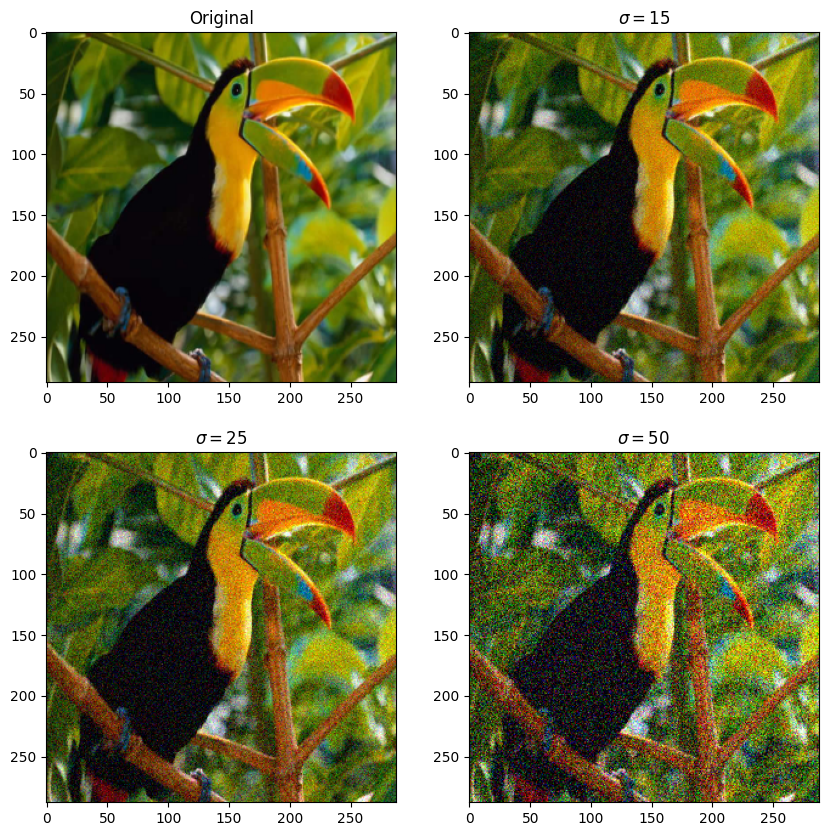

In [49]:
fig, ax = plt.subplots(2, 2, figsize=(10, 10))
imshow(ax[0, 0], img_L)
ax[0, 0].set_title("Original")

imshow(ax[0, 1], img_15)
ax[0, 1].set_title("$\\sigma=15$")

imshow(ax[1, 0], img_25)
ax[1, 0].set_title("$\\sigma=25$")

imshow(ax[1, 1], img_50)
ax[1, 1].set_title("$\\sigma=50$");

## Blind gaussian denoising with DnCNN
For blind denoising, the prior noise level is unknown

In [50]:
from models.network_dncnn import DnCNN
n_channels = 3
nb = 20
model_path = "../KAIR/model_zoo/dncnn_color_blind.pth"
dncnn = DnCNN(in_nc=n_channels, out_nc=n_channels, nc=64, nb=nb, act_mode="R")
dncnn.load_state_dict(torch.load(model_path), strict=True)

device = "cuda" if torch.cuda.is_available() else "cpu"
dncnn.eval()
dncnn = dncnn.to(device)

def denoise_dncnn(x):
    x = utils_image.single2tensor4(x).to(device)
    with torch.no_grad():
        denoised = dncnn(x)
    denoised = utils_image.tensor2single(denoised)
    return np.clip(denoised, 0, 1)

In [51]:
def psnr(x, y):
    return utils_image.calculate_psnr(
        utils_image.single2uint(x),
        utils_image.single2uint(y), border=0)
    
def ssim(x, y):
    return utils_image.calculate_ssim(
        utils_image.single2uint(x),
        utils_image.single2uint(y), border=0)

In [52]:
denoised_0  = denoise_dncnn(img_L)
denoised_15 = denoise_dncnn(img_15)
denoised_25 = denoise_dncnn(img_25)
denoised_50 = denoise_dncnn(img_50)

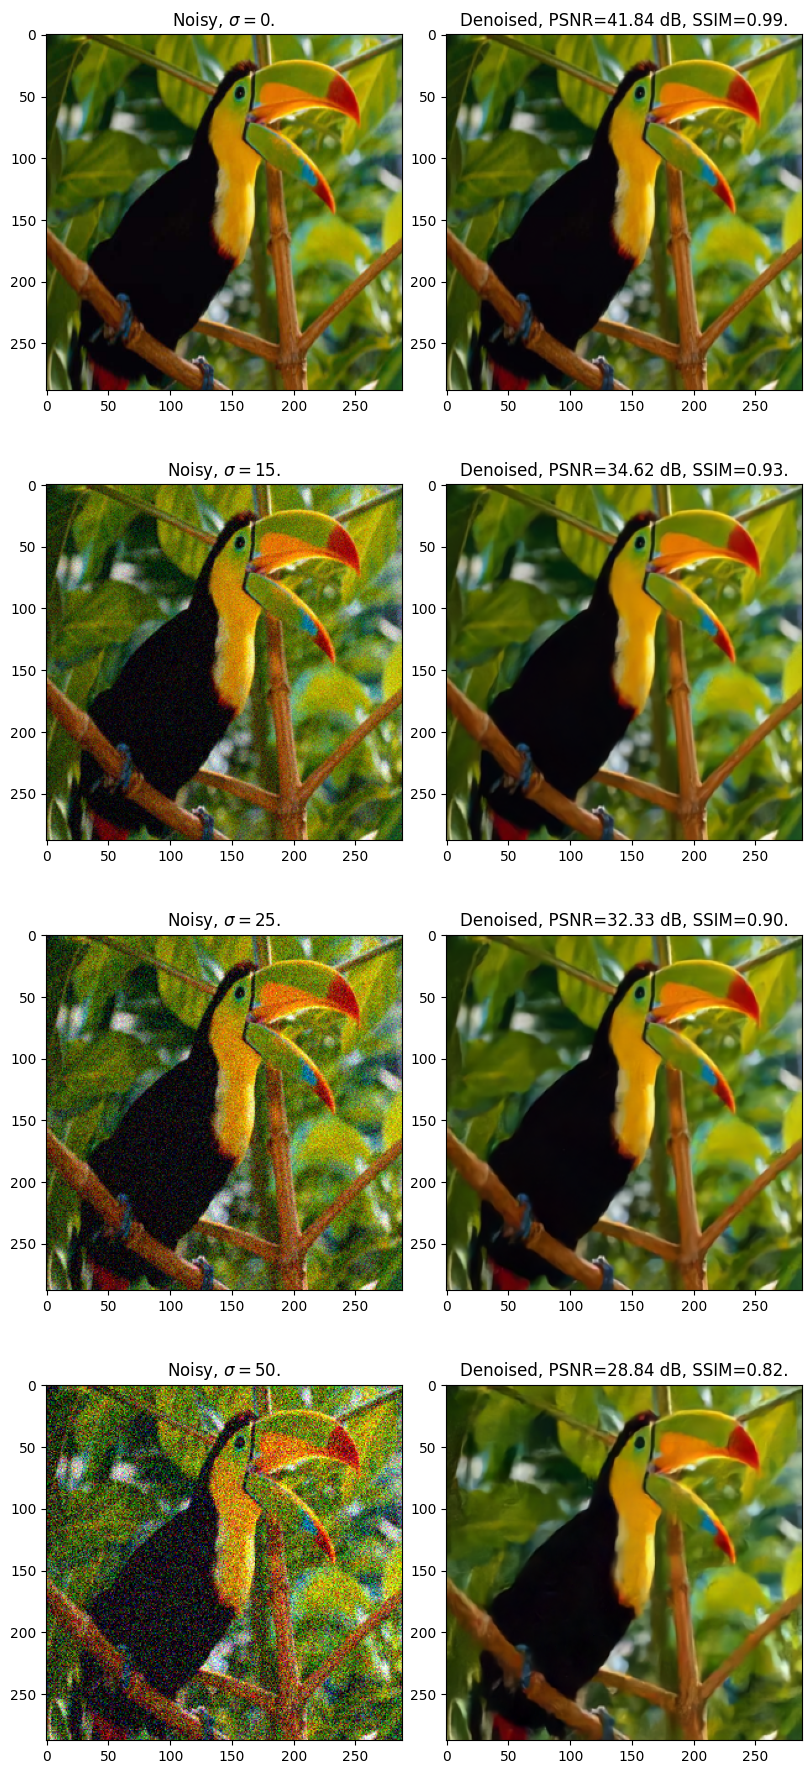

In [53]:
def plot_pair(ax, a, b, sigma):
    imshow(ax[0], a)
    imshow(ax[1], b)
    ax[0].set_title(f"Noisy, $\\sigma={sigma}$.")
    ax[1].set_title(f"Denoised, PSNR={psnr(img_L, b):.2f} dB, SSIM={ssim(img_L, b):.2f}.")

fig, ax = plt.subplots(4, 2, figsize=(8, 18), constrained_layout=True)
plot_pair(ax[0], img_L,  denoised_0,  sigma=0)
plot_pair(ax[1], img_15, denoised_15, sigma=15)
plot_pair(ax[2], img_25, denoised_25, sigma=25)
plot_pair(ax[3], img_50, denoised_50, sigma=50)

## Targeted denoising with SwinIR
You may try the pretrained models targeting different noise levels: 15, 25 and 50.

In [54]:
from types import SimpleNamespace
from main_test_swinir import define_model, setup

args = SimpleNamespace(
    task="color_dn",
    #model_path="../KAIR/model_zoo/swinir/005_colorDN_DFWB_s128w8_SwinIR-M_noise15.pth"
    #model_path="../KAIR/model_zoo/swinir/005_colorDN_DFWB_s128w8_SwinIR-M_noise25.pth"
    model_path="../KAIR/model_zoo/swinir/005_colorDN_DFWB_s128w8_SwinIR-M_noise50.pth"
)
swinir = define_model(args)
swinir = swinir.eval().to(device)

def denoise_swinir(x):
    x = utils_image.single2tensor4(x).to(device)
    with torch.no_grad():
        denoised = swinir(x)
    denoised = utils_image.tensor2single(denoised)
    return np.clip(denoised, 0, 1)

In [55]:
denoised_0  = denoise_swinir(img_L)
denoised_15 = denoise_swinir(img_15)
denoised_25 = denoise_swinir(img_25)
denoised_50 = denoise_swinir(img_50)

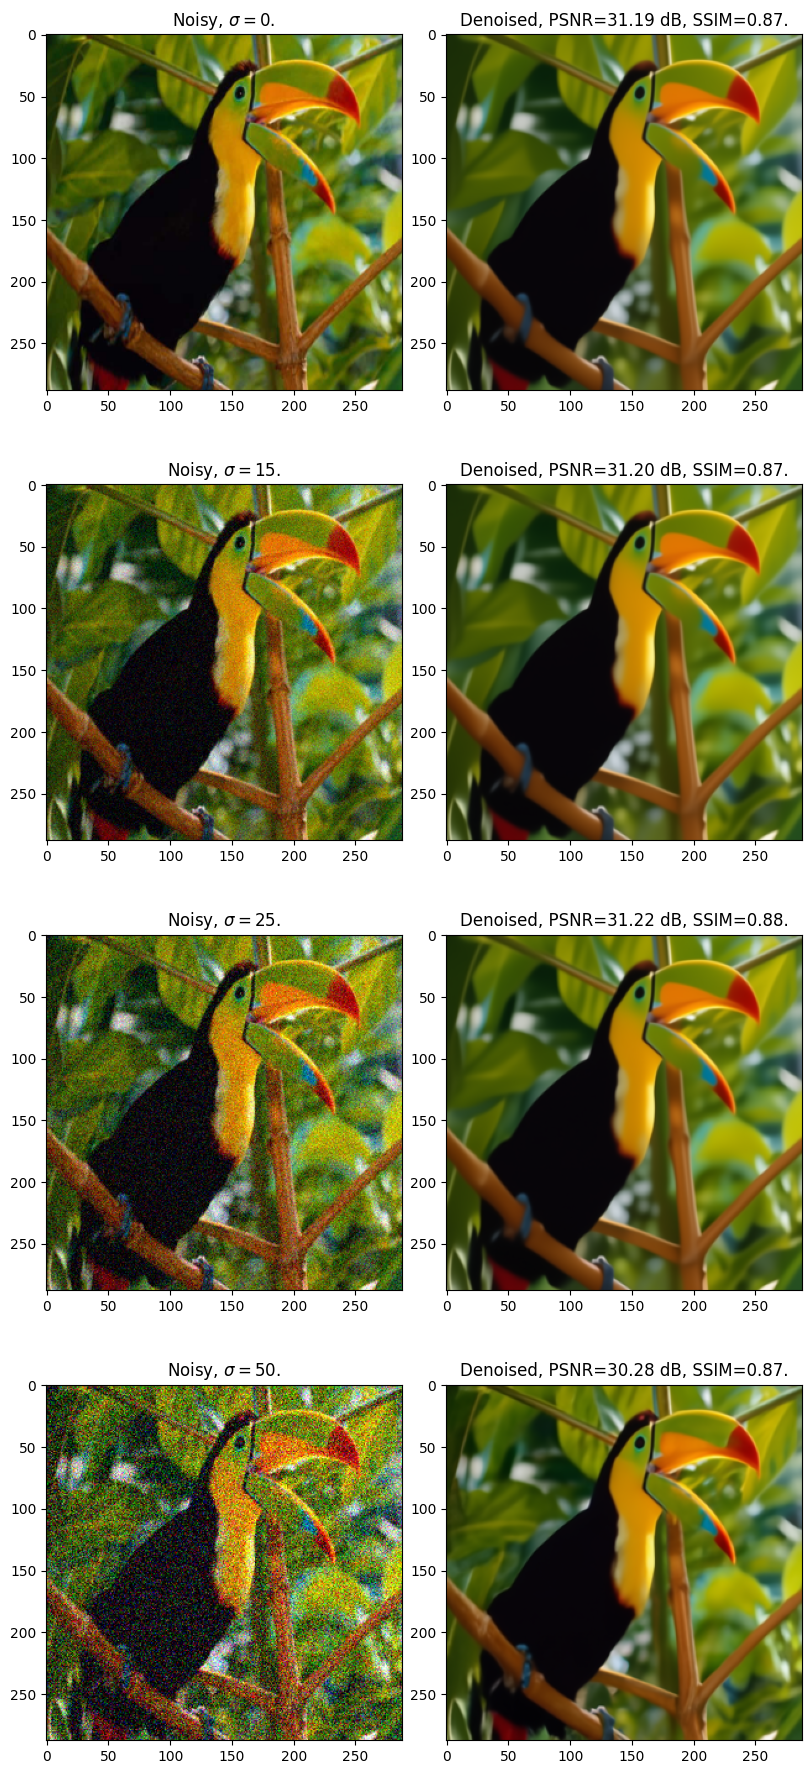

In [56]:
fig, ax = plt.subplots(4, 2, figsize=(8, 18), constrained_layout=True)
plot_pair(ax[0], img_L,  denoised_0,  sigma=0)
plot_pair(ax[1], img_15, denoised_15, sigma=15)
plot_pair(ax[2], img_25, denoised_25, sigma=25)
plot_pair(ax[3], img_50, denoised_50, sigma=50)

## An Idea:
Try to combine Super-Resolution and Denoising!
For instance, check what happens if you first Upscale an image, then denoise-it, then Downscale it back!